In [ ]:
from modeling.data.master import build_daily
from modeling.features import assemble_features
from modeling.metrics import mae, rmse, poisson_deviance
from modeling.models import build_model
from modeling.split import make_split
from modeling.evaluate import _load_run
import pickle
from types import SimpleNamespace
from omegaconf import DictConfig, OmegaConf
from typing import Any
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preprocess the files 

In [3]:
def get_model(filename: str):
    cfg = OmegaConf.create({'load_model': filename})
    model_path, run_cfg = _load_run(cfg)
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    model = saved["model"]
    feature_cols = saved["feature_cols"]
    feat_params = SimpleNamespace(**saved["feat_params"])
    return model, feature_cols, feat_params, run_cfg

In [4]:
def build_data(run_cfg: DictConfig, feat_params: Any):
    pothole_df, weather_df = build_daily(run_cfg)
    feat_df = assemble_features(pothole_df, weather_df, feat_params)
    feat_df = make_split(feat_df, run_cfg.split, feat_params)
    return feat_df

In [5]:
def get_results(f: str, horizon: int = 1): 
    model, feature_cols, feat_params, run_cfg = get_model(f)
    print(f"Feature params: {feat_params}")
    feat_df = build_data(run_cfg, feat_params)

    # get test data
    test_df = feat_df[feat_df["split"] == "test"]
    X_test = test_df[feature_cols]
    y_test = test_df["Y"]

    # get predictions
    y_test_preds = model.predict(X_test, recursive = True, horizon=horizon)

    return y_test, y_test_preds, test_df, model


# Plot a single result


In [26]:
f = "ward3_best_xgb_sarimax_d_7_20200601_20251231_20260321_f6d9b263"
model, feature_cols, feat_params, run_cfg = get_model(f)


In [27]:
print(f"Feature params: {feat_params}")
feat_df = build_data(run_cfg, feat_params)

Feature params: namespace(d=7, d_f=11, d_p=9, d_s=20, k_AR=0, l_f=5, l_p=9, l_s=10)
[assemble_features] kept 1819/1826 rows (99.6%) after dropping NaNs


In [28]:
# get test data
test_df = feat_df[feat_df["split"] == "test"]
X_test = test_df[feature_cols]
y_test = test_df["Y"]

In [29]:
# get predictions
y_test_preds = model.predict(X_test, recursive = True, horizon_h=1)

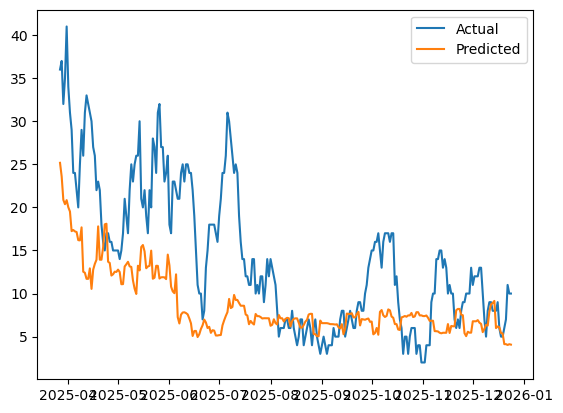

In [30]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(test_df.date, y_test, label="Actual")
ax.plot(test_df.date, y_test_preds, label="Predicted")
ax.legend()
plt.show()

FW2025 strict run dirs:
  negbin_glm       -> ward3_negbin_glm_fw2025_20200601_20251231_20260331_f6d9b4ff
  poisson_glm      -> ward3_poisson_glm_fw2025_20200601_20251231_20260331_7e1cf95f
  naive_last_week  -> ward3_naive_weekly_fw2025_20200601_20251231_20260331_54832a54
  naive_last_year  -> ward3_naive_yearly_fw2025_20200601_20251231_20260331_a2e8750e
  xgb              -> ward3_xgb_fw2025_20200601_20251231_20260331_0c1aa0f2
  xgb_sarimax      -> ward3_xgb_sarimax_fw2025_20200601_20251231_20260331_2622f323
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
Feature params: namespace(d=1, d_p=15, l_p=10, d_s=15, l_s=0, d_f=15, l_f=0, k_AR=0)
[assemble_features] kept 1825/1826 rows (99.9%) after dropping NaNs
[assemble_features] kept 1

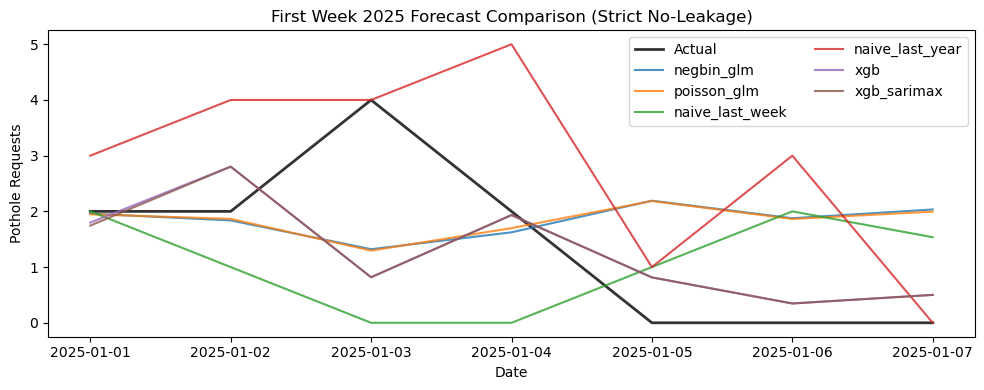

First-week-2025 metrics (sorted by MAE):


,Model,MAE,RMSE,Rel. MAE (%),Rel. RMSE (%),poisson_deviance,run_dir
0,xgb,0.845319,1.301279,0.332775,0.448792,1.420243,ward3_xgb_fw2025_20200601_20251231_20260331_0c...
1,xgb_sarimax,0.852741,1.302716,0.339578,0.450513,1.422413,ward3_xgb_sarimax_fw2025_20200601_20251231_202...
2,poisson_glm,1.319482,1.675739,0.229935,0.348166,2.251439,ward3_poisson_glm_fw2025_20200601_20251231_202...
3,negbin_glm,1.337360,1.682448,0.239784,0.350315,2.258344,ward3_negbin_glm_fw2025_20200601_20251231_2026...
4,naive_last_year,1.428571,1.851640,0.750000,0.935414,1.705770,ward3_naive_yearly_fw2025_20200601_20251231_20...
5,naive_last_week,1.647998,2.012789,0.625000,0.750000,33.250810,ward3_naive_weekly_fw2025_20200601_20251231_20...


Naive rule checks:


,Model,Exact matches
0,naive_last_week,6/7
1,naive_last_year,7/7


In [5]:
from pathlib import Path
import yaml

WEEK_START = pd.Timestamp("2025-01-01")
WEEK_END = pd.Timestamp("2025-01-07")

FW_PREFIX = {
    "negbin_glm": "ward3_negbin_glm_fw2025_",
    "poisson_glm": "ward3_poisson_glm_fw2025_",
    "naive_last_week": "ward3_naive_weekly_fw2025_",
    "naive_last_year": "ward3_naive_yearly_fw2025_",
    "xgb": "ward3_xgb_fw2025_",
    "xgb_sarimax": "ward3_xgb_sarimax_fw2025_",
}


def latest_stem_by_prefix(prefix: str, require_strict: bool = True) -> str:
    dirs = [d for d in Path("results").iterdir() if d.is_dir() and d.name.startswith(prefix)]
    if require_strict:
        filtered = []
        for d in dirs:
            run_cfg_path = d / "run.yaml"
            if not run_cfg_path.exists():
                continue
            try:
                run_data = yaml.safe_load(run_cfg_path.read_text())
            except Exception:
                continue
            leakage = run_data.get("leakage") or {}
            ok = bool(leakage.get("strict_no_leak", False)) and str(leakage.get("naive_mode", "")) == "strict"
            if ok:
                filtered.append(d)
        dirs = filtered

    if not dirs:
        raise FileNotFoundError(f"No run found for prefix: {prefix}")
    return sorted(dirs, key=lambda d: d.stat().st_mtime, reverse=True)[0].name


fw_runs = {}
missing_fw = []
for model_name, prefix in FW_PREFIX.items():
    try:
        fw_runs[model_name] = latest_stem_by_prefix(prefix, require_strict=True)
    except FileNotFoundError:
        missing_fw.append((model_name, prefix))

print("FW2025 strict run dirs:")
for k, v in fw_runs.items():
    print(f"  {k:16s} -> {v}")
if missing_fw:
    print("Missing strict runs for:")
    for model_name, prefix in missing_fw:
        print(f"  {model_name:16s} (prefix={prefix})")

plot_rows = []
metrics_rows = []
naive_checks = []
actual_week = None
dates_week = None

for model_key, stem in fw_runs.items():
    y_test, y_pred, test_df, model = get_results(stem)

    dates = pd.to_datetime(test_df["date"]).reset_index(drop=True)
    y_arr = np.asarray(y_test)
    p_arr = np.asarray(y_pred)

    mask = ((dates >= WEEK_START) & (dates <= WEEK_END)).to_numpy()
    dates_w = dates[mask]
    y_w = y_arr[mask]
    p_w = p_arr[mask]

    if len(y_w) != 7:
        raise ValueError(f"{model.name} has {len(y_w)} rows in first week 2025, expected 7")

    if actual_week is None:
        actual_week = y_w
        dates_week = dates_w

    plot_rows.append({
        "Model": model.name,
        "dates": dates_w,
        "pred": p_w,
    })

    metrics_rows.append({
        "Model": model.name,
        "MAE": mae(y_w, p_w),
        "RMSE": rmse(y_w, p_w),
        "Rel. MAE (%)": relative_mae(y_w, p_w),
        "Rel. RMSE (%)": relative_rmse(y_w, p_w),
        "poisson_deviance": poisson_deviance(y_w, p_w),
        "run_dir": stem,
    })

    if model.name in {"naive_last_week", "naive_last_year"}:
        feat_df = build_data(get_model(stem)[3], get_model(stem)[2])
        feat_df = feat_df.sort_values("date").reset_index(drop=True)
        feat_df["date"] = pd.to_datetime(feat_df["date"]).dt.normalize()
        y_map = dict(zip(feat_df["date"], feat_df["Y"]))

        exact = 0
        for dt, pred in zip(dates_w, p_w):
            dt = pd.Timestamp(dt).normalize()
            if model.name == "naive_last_week":
                ref = dt - pd.Timedelta(days=7)
            else:
                try:
                    ref = pd.Timestamp(year=dt.year - 1, month=dt.month, day=dt.day)
                except ValueError:
                    ref = pd.Timestamp(year=dt.year - 1, month=2, day=28)
            if abs(pred - y_map.get(ref, np.nan)) < 1e-9:
                exact += 1
        naive_checks.append({"Model": model.name, "Exact matches": f"{exact}/7"})



if not plot_rows:
    print("No strict FW2025 runs available. Please train strict runs first.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(dates_week, actual_week, label='Actual', color='black', linewidth=2, alpha=0.8)
    for row in plot_rows:
        ax.plot(row['dates'], row['pred'], label=row['Model'], alpha=0.8)

    ax.set_title('First Week 2025 Forecast Comparison (Strict No-Leakage)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Pothole Requests')
    ax.legend(loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_rows).sort_values('MAE').reset_index(drop=True)
    print('First-week-2025 metrics (sorted by MAE):')
    display(metrics_df)

    if naive_checks:
        print('Naive rule checks:')
        display(pd.DataFrame(naive_checks))

